In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
#1
df = pd.read_csv("residential_housing.csv")
missing_per_column = df.isna().sum()
total_missing = missing_per_column.sum()

print(missing_per_column)
print("Total missing values:", total_missing)

Id                 0
MSSubClass       163
MSZoning           0
LotFrontage      397
LotArea          154
Street             0
Alley              0
Utilities          0
LandSlope          0
Condition2         0
BldgType           0
OverallQual      100
OverallCond      159
YearBuilt        120
YearRemodAdd     117
RoofMatl           0
MasVnrArea       139
ExterQual          0
Foundation         0
BsmtQual           0
BsmtCond           0
BsmtExposure       0
BsmtFinSF1       101
BsmtFinSF2       117
BsmtUnfSF         68
TotalBsmtSF      102
Heating            0
CentralAir         0
Electrical         0
1stFlrSF         119
2ndFlrSF          52
LowQualFinSF      69
GrLivArea        107
BsmtFullBath     140
BsmtHalfBath      96
FullBath         139
HalfBath          67
BedroomAbvGr      53
KitchenAbvGr     119
TotRmsAbvGrd     124
Fireplaces        70
FireplaceQu        0
GarageType         0
GarageYrBlt      150
GarageCars       142
GarageArea        91
GarageQual         0
WoodDeckSF   

Number of tuples with specific missing values (1–9):
1    295
2    384
3    331
4    188
5     90
6     30
7     10
8      7
9      1
Name: count, dtype: int64


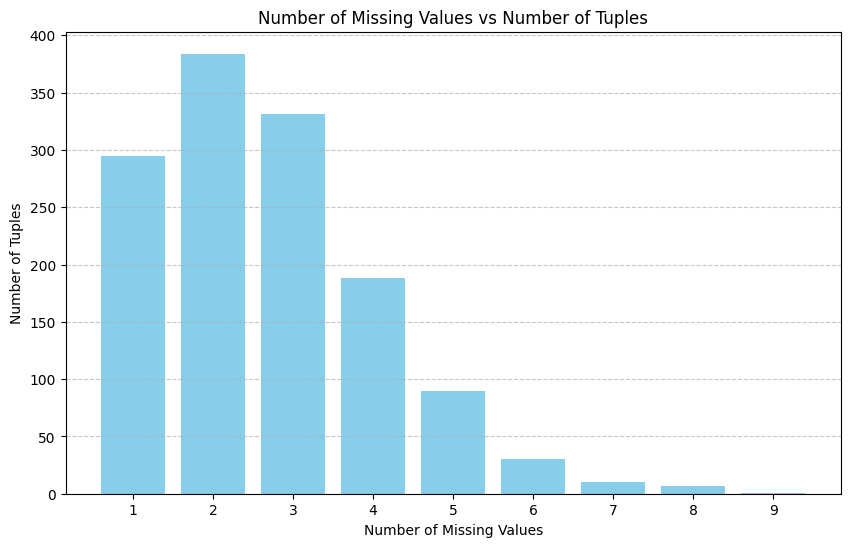

In [8]:
#2a
# Count missing values per row
missing_counts = df.isnull().sum(axis=1)

# Keep only rows with 1 to 9 missing values
missing_counts = missing_counts[missing_counts.between(1, 9)]

# Count tuples per missing-value count
missing_value_distribution = (
    missing_counts
    .value_counts()
    .reindex(range(1, 10), fill_value=0)
    .sort_index()
)

print("Number of tuples with specific missing values (1–9):")
print(missing_value_distribution)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(
    missing_value_distribution.index,
    missing_value_distribution.values,
    color='skyblue'
)
plt.xlabel('Number of Missing Values')
plt.ylabel('Number of Tuples')
plt.title('Number of Missing Values vs Number of Tuples')
plt.xticks(range(1, 10))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
#2b
threshold = len(df.columns) / 2

tuples_with_high_missing = (missing_value_distribution >= threshold).sum()
print(f"Number of tuples with >=50% of attributes missing: {tuples_with_high_missing}")

Number of tuples with >=50% of attributes missing: 6


In [14]:
#2c
threshold = 0.5 * df.shape[1]  # 50% of total attributes 

df_cleaned = df.dropna(thresh=df.shape[1] - threshold)

print(f"After dropping tuples with >=50% missing values, the dataset has {len(df_cleaned)} rows.")


After dropping tuples with >=50% missing values, the dataset has 1458 rows.


In [16]:
#2d
df_target_cleaned = df_cleaned.dropna(subset=['SalePrice'])
print(f"After dropping tuples with missing 'quality' attribute, the dataset has {len(df_target_cleaned)} rows.")

After dropping tuples with missing 'quality' attribute, the dataset has 1410 rows.


In [18]:
#2e
df_target_cleaned.to_csv('residential_housing_updated.csv', index=False)
print("Cleaned dataset saved as 'residential_housing.csv'.")

Cleaned dataset saved as 'residential_housing.csv'.
